# Geometric Hypergraph Embedding

In [1]:
import networkx as nx
import numpy as np
import scipy as sp
import hypernetx as hnx
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib as mpl
from IPython.display import HTML
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, roc_curve, auc
import time

## Definitions

### RGH model

We fix notation for the following hypergraph representations:
- *Hypergraph* $H$: a hypergraph with $n$ nodes $u_1,\dots,u_n$ and $s$ hyperedges $h_1,\dots,h_s$.
- *Incidence matrix* $B$: a $n\times s$ matrix such that $B_{ij}=1$ if and only if $u_i\in h_j$ in $H$.
- *Bipartite graph* $G$: the incidence graph of $H$, with $n+s$ nodes $u_1,\dots,u_n,h_1,\dots,h_s$.
- *Embedding* $Y$ of $G$: an $(n+s)\times D$ matrix 
  $\begin{bmatrix}Y_u\\Y_h\end{bmatrix}$, where the first $n$ rows, denoted by $Y(u_1),\dots,Y(u_n)$, give the 
  $D$-dimensional coordinates of $u_1,\dots,u_n$, and the last $s$ rows, $Y(h_1),\dots,Y(h_s)$
  give the coordinates of $h_1,\dots,h_s$.

According to the Random Geometric Hypergraph (RGH) model, given a random Euclidean embedding $Y$, a node $u_i$ belongs 
to a hyperedge $h_j$ if and only if the corresponding embeddings are within 
distance $r$, where $r$ is a fixed radius. Here, we address the inverse problem: given $H$, we aim to find 
a suitable embedding and radius such that the above condition is satisfied for every node 
and hyperedge.

In [2]:
# Incidence graph from hypergraph
def hypergraph_to_bipartite(H):
    G = nx.Graph()
    node_ids = {}
    hedge_ids = {}
    for i, u in enumerate(H.nodes):
        node_ids[u] = f'u{i}'
        G.add_node(node_ids[u], bipartite=1)
    for j, h in enumerate(H.edges):
        hedge_ids[h] = f'h{j}'
        G.add_node(hedge_ids[h], bipartite=0)
    for h in H.edges:
        for u in H.edges[h]:
            G.add_edge(node_ids[u], hedge_ids[h])
    return G

# Bipartite graph from incidence graph
def bipartite_to_hypergraph(G):
    if len(G.edges) == 0:
        print('No hyperedges')
        H = None
    else:
        H = hnx.Hypergraph.from_bipartite(G)
    return H

# Geometric model to compute bipartite graph
# from embedding Y and radius r
def random_geometric_model(n, s, D, r, random_seed=0):
    np.random.seed(random_seed)
    Yu, Yh = random_euclidean(n, s, D)
    G = embedding_to_bipartite(Yu, Yh, r)
    H = bipartite_to_hypergraph(G)
    if not nx.is_connected(G):
        print('Warning: the generated graph is not connected.')
    return (Yu, Yh), G, H

def random_euclidean(n, s, D):
    Yu, Yh = np.zeros((n,D)), np.zeros((s,D))
    for i in range(n):
        Yu[i] = np.random.random(D)
    for j in range(s):
        Yh[j] = np.random.random(D)
    return Yu, Yh

def embedding_to_bipartite(Yu, Yh, r):
    n, s = len(Yu), len(Yh)
    G = nx.Graph()
    for i in range(n):
        G.add_node(f'u{i}', bipartite=1)
    for j in range(s):
        G.add_node(f'h{j}', bipartite=0)
        for i in range(n):
            if np.linalg.norm(Yu[i]-Yh[j]) < r:
                G.add_edge(f'u{i}', f'h{j}')
    return G

# Imports hypergraph from text file
def import_txt(filename):
    hedges = {}
    with open(filename) as f:
        for h, line in enumerate(f):
            nodes = list(map(int, line.strip().split(',')))
            hedges[h] = nodes
    H = hnx.Hypergraph(hedges)
    G = hypergraph_to_bipartite(H)
    return H, G

### Drawing

In [3]:
def draw_embedding(Yu, Yh, dims=[0,1], r=None, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    ax.set_aspect('equal')
    n, s = len(Yu), len(Yh)
    for i in range(n):
        x, y = Yu[i][dims[0]], Yu[i][dims[1]]
        ax.scatter(x, y, s=0)
        ax.text(x, y, f'u{i}', c='b', horizontalalignment='center', verticalalignment='center')
    for j in range(s):
        x, y = Yh[j][dims[0]], Yh[j][dims[1]]
        ax.scatter(x, y, s=0) 
        ax.text(x, y, f'h{j}', c='r', horizontalalignment='center', verticalalignment='center')
        if r is not None:
            ax.add_patch(plt.Circle((x,y), r, color='r', alpha=.1))

def draw_bipartite(G, ax=None):
    # Assumption: G0 nodes u_1,...,u_n should have the flag "bipartite" set to 1
    if ax is None:
        _, ax = plt.subplots()
    pos = nx.bipartite_layout(G, [u for u in G if G.nodes[u]['bipartite'] == 1])
    nx.draw(G, ax=ax, pos=pos, with_labels=True, font_size=8, node_color='w')

def draw_hypergraph(H, ax=None):
    if ax is None:
        _, ax = plt.subplots()
    if H is not None:
        hnx.draw(H, ax=ax)

### Example of RGH model

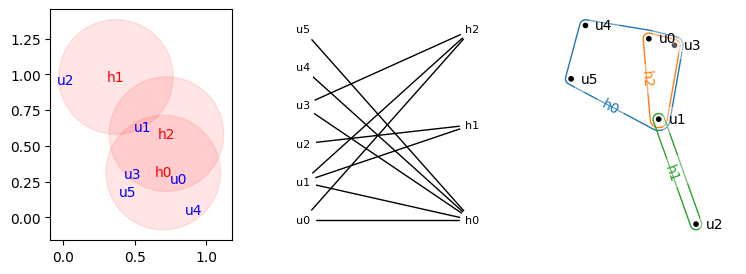

In [4]:
n, s, D, r = 6, 3, 2, 0.4
(Yu, Yh), G, H = random_geometric_model(n, s, D, r, random_seed=175)

fig, axs = plt.subplots(1, 3, figsize=(9,3))
draw_embedding(Yu, Yh, r=r, ax=axs[0])
draw_bipartite(G, ax=axs[1])
draw_hypergraph(H, ax=axs[2])

### Spectral embedding

Let $H$ be a hypergraph with incidence matrix $B$, and let $G$ be the associated bipartite graph. Assume that $G$ is connected and has Laplacian matrix $L$. Let $\lambda_1\le\dots\le\lambda_{n-1}$ be the $n-1$ nonzero eigenvalues of $L$ and let $v^{(1)},\dots,v^{(n-1)}$ be the corresponding eigenvectors. Then, we let $Y^{\mathrm{sp}}(B)$ be the *spectral embedding* of $G$, given by
$$
Y^{\mathrm{sp}}(B)
=\left[\begin{array}{c|c|c}
v^{(1)} & \dots & v^{(D)}
\end{array}\right],
$$
The spectral embedding $Y^{\mathrm{sp}}(B)$ minimizes the quantity
$$
\sum_{i=1}^n\sum_{j=1}^sB_{ij}\left\|Y(u_i)-Y(h_j)\right\|_2^2,
$$
over all possible $D$-dimensional embeddings $Y\in\mathbb{R}^{n\times D}$.

In [5]:
def spectral_embedding(B, D=None, centroids=False, last_Y=None):
    r"""
    Given the incidence matrix B of a connected hypergraph H, computes the D-dimensional
    spectral embedding (Yu, Yh) of the corresponding incidence graph G.
    If D is unspecified, returns the full spectrum (except λ=0) and eigenvectors.
    If last_Y is given, chooses the sign of the column of Y via Y_choose_sign.
    If centroids=True, computes the faster initial embedding Y^c,
    using the spectral embedding of BB^\transpose for u_1,...,u_n,
    and the centroids of the relevant nodes for h_1,...,h_n
    """
    n, s = B.shape
    if centroids:
        BBt = B @ np.transpose(B)
        L = np.diag(BBt @ np.ones(n)) - BBt
    else:
        A = np.zeros((n+s, n+s))
        A[:n,n:n+s] = B
        A += np.transpose(A)
        L = np.diag(A @ np.ones(len(A))) - A
    if D is None or D >= n+s-1:
        λ, Y = np.linalg.eigh(L)
    else:
        λ, Y = sp.sparse.linalg.eigsh(L, k=D+1, which='SA')
    zero_index = np.argmin(np.abs(λ))
    λ = np.delete(λ, zero_index)
    Y = np.delete(Y, zero_index, 1)
    Y = Y_choose_sign(Y, last_Y)
    if centroids:
        Yu = Y
        ws = np.ones(n) @ B
        ws[ws == 0] = 1
        wA = B @ np.diag(1 / ws)
        Yh = np.transpose(wA) @ Yu
    else:
        Yu, Yh = Y[:n], Y[n:]
    return λ, Yu, Yh

# Chooses the sign of each column of Y so that it has nonnegative
# scalar product with the corresponding column of last_Y.
def Y_choose_sign(Y, last_Y=None):
    if last_Y is not None:
        for j in range(Y.shape[1]):
            if last_Y[:,j] @ Y[:,j] < 0:
                Y[:,j] *= -1
    return Y

### Embedding optimization

We are looking for both a $D$-dimensional embedding $Y$ of the nodes of the incidence graph $G^{(0)}$ of $H^{(0)}$, and a radius $r$, such that $G^{(0)}$ can be recovered by applying the geometric hypergraph model to the points of the embedding. 
We define the loss function
$$
\mathcal{L}(Y,r)=\dfrac{\bigl\|\tilde B(Y,r)-B^{(0)}\bigr\|^2_{\mathrm{fro}}}{\bigl\|B^{(0)}\bigr\|^2_{\mathrm{fro}}},
$$
where $B^{(0)}$ is the incidence matrix of $H^{(0)}$ and
$$\tilde B_{ij}(Y,r)=
\begin{cases}
    1 & \text{if $d_{ij}(Y)\le r$}\\
    0 & \text{otherwise,}
\end{cases}
$$
is the incidence matrix of the recovered graph from the embeddding. Here $d_{ij}(Y)$ denotes the euclidean distance between $Y(u_i)$ and $Y(h_j)$.

In [6]:
# Reconstructed incidence matrix \tilde B
def reconstruction(Yu, Yh, r):
    return 1-np.heaviside(cdist(Yu, Yh)-r, 0)

# Loss function (MSE)
def mse_approx_loss(B_tau, B0):
    return np.linalg.norm(B_tau-B0, 'fro')**2 / np.linalg.norm(B0, 'fro')**2

To make the loss function  differentiable with respect to $B$, we approximate the discontinuous step function with the differentiable function
$$
f_\tau(x,r)=\dfrac{1}{1+e^{\tau^2(x^2-r^2)}},
$$
and define the *approximated loss function*
$$
[\tilde B_\tau]_{ij}(Y,r)=f_\tau\bigl(d_{ij}(Y),r\bigr).
$$

In [7]:
# Approximation of the heaviside function with a modified logistic function
def lf(x, r, tau):
    return 1/(1+np.exp(tau**2 * (x**2-r**2)))
def dlf_dx(x, r, tau):
    return -tau**2*np.exp(tau**2 * (x**2-r**2))*lf(x,r,tau)**2 * 2#*x
    # here we do not multiply by x, in dloss_GDSE and dloss_GDE we do not divide
def dlf_dr(x, r, tau):
    return tau**2*np.exp(tau**2 * (x**2-r**2))*lf(x,r,tau)**2 * 2*r
def dlf_dtau(x, r, tau):
    return -(x**2-r**2)*np.exp(tau**2 * (x**2-r**2))*lf(x,r,tau)**2 * 2*tau

# Reconstructed approximated incidence matrix \tilde B_\tau
def approx_reconstruction(Yu, Yh, r, tau):
    return lf(cdist(Yu, Yh), r, tau)

### Gradient Descent Spectral Embedding (GDSE)

GDSE tries to minimize the loss function $\mathcal{L}(Y,r)$
with the extra constraint
$$
Y = Y^{\mathrm{sp}}(B),
$$
i.e., $Y$ is the spectral embedding of the hypergraph with incidence matrix $B$,
where $B$ is a suitable perturbation of $B^{(0)}$, the incidence matrix of $H^{(0)}$. With the notation introduced for spectral embedding, we have
$$\begin{split}
\dfrac{\partial\mathcal{L}_\tau\bigl(Y^{\mathrm{sp}}(B),r\bigr)}{\partial B}
&=\dfrac{1}{\bigl\|B^{(0)}\bigr\|^2_{\mathrm{fro}}}\sum_{k=1}^D\sum_{h=D+1}^{N}\dfrac{\mathrm{sum}\bigl(S\odot V^{(k)} \odot V^{(h)}\bigr)}{\lambda_k-\lambda_h}\:V^{(k)} \odot V^{(h)}\\
\dfrac{\partial\mathcal{L}_\tau\bigl(Y^{\mathrm{sp}}(B),r\bigr)}{\partial r}&=
\dfrac{1}{\bigl\|B^{(0)}\bigr\|^2_{\mathrm{fro}}}\sum_{i=1}^n\sum_{j=1}^{s}2\left([\tilde B_\tau]_{ij}-B^{(0)}_{ij}\right)\dfrac{\partial f_\tau}{\partial r}(d_{ij}, r)\\
\dfrac{\partial\mathcal{L}_\tau\bigl(Y^{\mathrm{sp}}(B),r\bigr)}{\partial \tau}&=
\dfrac{1}{\bigl\|B^{(0)}\bigr\|^2_{\mathrm{fro}}}\sum_{i=1}^n\sum_{j=1}^{s}2\left([\tilde B_\tau]_{ij}-B^{(0)}_{ij}\right)\dfrac{\partial f_\tau}{\partial \tau}(d_{ij}, r)
\end{split}
$$
where $V^{(k)}_{ij}=v_i^{(k)}-v_j^{(k)}$ and
$$
S_{ij} = \dfrac{2\Bigl([\tilde B_\tau]_{ij}-B_{ij}^{(0)}\Bigr) \dfrac{\partial f_\tau}{\partial d_{ij}}(d_{ij}, r)}{d_{ij}}.
$$

In [8]:
def GDSE(G0, D=2, iter=1000, tol=None, step_size=.1, r_step_size=.001, tau_step_size=1, r0=0.1, tau0=5, print_history=False, print_result=True, return_history=False):
    r"""
    Gradient Descent Embedding (GDSE) optimization.
    Given a the incidence graph G0 of hypergraph H0, computes a D-dimensional
    spectral embedding (Yu, Yh) through gradient-descent (GD) iterations,
    optimizing the weights of adjacency matrix.
        - G0: bipartite incidence graph
        - D: embedding dimension
        - iter: number of GD iterations
        - tol: if loss<tol the algorithms stops
        - step_size, r_step_size, tau_step_size: step size in GD
        - r0, tau0: initial values
        - print_history: prints logs during executions
        - print_result: print summary of execution at the end
        - return_history: see Returns.
    Returns:
        - Yu, Yh, r, tau: resulting embedding, r, and \tau
        - history: also returned if returns_history==True; it is a dictionary with keys
            - 'approx_loss': list of approximated loss \mathcal L_\tau
            - 'loss': list of loss \mathcal L
            - 'B': list of the of the weights of B over iterations
            - 'Yu', 'Yh', 'r', 'tau': progress of the embedding Y, r, and \tau     
    Assumption: G0 nodes u_1,...,u_n should have the flag "bipartite" set to 1,
    i.e. G0.nodes['bipartite'] = 1, while h_1,...,h_n should have it set to 0.
    """
    tic = time.time()

    n = len([u for u in G0.nodes if G0.nodes[u]['bipartite'] == 1])
    s = len([u for u in G0.nodes if G0.nodes[u]['bipartite'] == 0])
    if n+s != len(G0):
        print('Something wrong with the "bipartite" flag')

    # Initialization
    r, tau = r0, tau0
    B0 = nx.to_numpy_array(G0)[:n,n:n+s]

    B = np.copy(B0)
    λ, Yu, Yh = spectral_embedding(B, D=D)
    B_tau = approx_reconstruction(Yu, Yh, r, tau)
    B_ = reconstruction(Yu, Yh, r)
    approx_loss, loss = mse_approx_loss(B_tau, B0), mse_approx_loss(B_, B0)

    if return_history:
        approx_loss_list = [approx_loss]
        loss_list = [loss]
        B_list = [np.copy(B)]
        Yu_list = [np.copy(Yu)]
        Yh_list = [np.copy(Yh)]
        r_list = [r]
        tau_list = [tau]

    for epoch in range(iter):
        
        # Gradient step
        dloss_dA, dloss_dr, dloss_dtau = dloss_GDSE(B_tau, B, B0, D, r, tau, λ, Yu, Yh)
        dA = -step_size * dloss_dA
        dr = -r_step_size * dloss_dr
        dtau = -tau_step_size * dloss_dtau
        B += dA
        r = np.abs(r+dr)
        tau = np.abs(tau+dtau)

        # Metrics
        λ, Yu, Yh = spectral_embedding(B, D=D, last_Y=np.vstack((Yu,Yh)))
        B_tau = approx_reconstruction(Yu, Yh, r, tau)
        B_ = reconstruction(Yu, Yh, r)
        approx_loss, loss = mse_approx_loss(B_tau, B0), mse_approx_loss(B_, B0)
        if return_history:
            r_list.append(r)
            tau_list.append(tau)
            loss_list.append(loss)
            approx_loss_list.append(approx_loss)
            B_list.append(np.copy(B))
            Yu_list.append(np.copy(Yu))
            Yh_list.append(np.copy(Yh))

        # Print
        if print_history:
            print(f'Ep. {epoch+1:3d}, approx_loss={approx_loss:.6f}, loss={loss:.6f}, r={r:.6f}, tau={tau:.2f}, D={D}')

        # Termination
        if tol is not None and loss <= tol:
            break

    toc = time.time()

    if print_result:
        print(f'GDSE Result: ep. {iter}, approx_loss={approx_loss:.6f}, loss={loss:.6f}, r={r:.6f}, tau={tau:.2f}, D={D}, time elapsed: {toc-tic:.2f}s')
    if return_history:
        history = {'approx_loss':approx_loss_list, 'loss':loss_list, 'B':B_list, 'Yu':Yu_list, 'Yh':Yh_list, 'r':r_list, 'tau':tau_list}
        return Yu, Yh, r, tau, history
    else:
        return Yu, Yh, r, tau

# Derivative of GDSE approx_loss function w.r.t. B, r, tau
def dloss_GDSE(B_tau, B, B0, D, r, tau, λ, Yu, Yh):
    λ, Yu, Yh = spectral_embedding(B, D=None, last_Y=None)
    n, s = B0.shape
    dloss_dr = 0
    dloss_dtau = 0
    S = np.zeros((n,s))
    for u in range(n):
        for h in range(s):
            d_uh = np.linalg.norm(Yu[u,:D] - Yh[h,:D])
            dloss_dr += 2 * (B_tau[u,h]-B0[u,h]) * dlf_dr(d_uh, r, tau)
            dloss_dtau += 2 * (B_tau[u,h]-B0[u,h]) * dlf_dtau(d_uh, r, tau)
            S[u,h] = 2 * (B_tau[u,h] - B0[u,h]) * dlf_dx(d_uh, r, tau) #/ d_u #  # see dlf_dx
    X = np.zeros((n+s, n, s))
    for i in range(n+s-1):
        X[i] = Yu[:,[i]] @ np.ones((1,s)) - np.ones((n,1)) @ np.transpose(Yh[:,[i]])
    dloss_dA = np.zeros((n,s))
    for i in range(D):
        for j in range(D, n+s-1):
            dloss_dA += np.sum(S * X[i] * X[j]) / (λ[i]-λ[j]) * X[i] * X[j]
    
    nor = np.linalg.norm(B0, 'fro')**2
    return dloss_dA/nor, dloss_dr/nor, dloss_dtau/nor

### Gradient Descent Embedding (GDE)

GDE directly optimizes the embedding matrix $Y$ via gradient descent on the approximated loss $\mathcal{L}_\tau(Y,r)$. As in GDSE, both $r$ and $\tau$ are also optimized by the algorithm. We have
$$\begin{split}
\dfrac{\partial\mathcal L_\tau}{\partial Y(u_i)}
&=2\sum_{j=1}^{s}\left(\tilde B_{ij}-B^{(0)}_{ij}\right)\dfrac{\partial f_\tau}{d_{ij}}(d_{ij}, r)\dfrac{Y(u_i)-Y(h_j)}{d_{ij}},\quad\text{for $i=1,\dots,n$}\\
\dfrac{\partial\mathcal L_\tau}{\partial Y(h_j)}&=2\sum_{i=1}^{n}\left(\tilde B_{ij}-B^{(0)}_{ij}\right)\dfrac{\partial f_\tau}{d_{ij}}(d_{ij}, r)\dfrac{Y(h_j)-Y(u_i)}{d_{ij}},\quad\text{for $j=1,\dots,s$,}
\end{split}
$$
while the derivatives with respect to $r$ and $\tau$ are the same as in GDSE.

In [9]:
def GDE(G0, D=2, iter=1000, tol=None, batch_size=None, r0=0.1, tau0=5, start=None, print_history=False, print_result=True, return_history=False, random_seed=0):
    r"""
    Gradient Descent Embedding (GDE) optimization.
    Given a the incidence graph G0 of hypergraph H0, computes a D-dimensional
    embedding (Yu, Yh) through gradient-descent (GD) iterations,
    directly optimizing the embedding Y.
        - G0: bipartite incidence graph
        - D: embedding dimension
        - iter: number of GD iterations
        - tol: if loss<tol the algorithms stops
        - batch_size: size of random subset of nodes/hyperedges used to compute dloss_dY
        - r0, tau0: initial values
        - start: options for initial embedding; can be
            - None (standard spectral embedding)
            - 'centroid': computes the faster centroid-based initial embedding
            - 'random': random initial embedding
            - (Yu, Yh): given initial embedding
        - print_history: prints logs during executions
        - print_result: print summary of execution at the end
        - return_history: see Returns.
        - random_seed: seed for randomess, which occurs if batch_size is not None
    Returns:
        - Yu, Yh, r, tau: resulting embedding, r, and \tau
        - history: also returned if returns_history==True; it is a dictionary with keys
            - 'approx_loss': list of approximated loss \mathcal L_\tau
            - 'loss': list of loss \mathcal L
            - 'Yu', 'Yh', 'r', 'tau': progress of the embedding Y, r, and \tau     
    Assumption: G0 nodes u_1,...,u_n should have the flag "bipartite" set to 1,
    i.e. G0.nodes['bipartite'] = 1, while h_1,...,h_n should have it set to 0.
    """
    tic = time.time()

    n = len([u for u in G0.nodes if G0.nodes[u]['bipartite'] == 1])
    s = len([u for u in G0.nodes if G0.nodes[u]['bipartite'] == 0])
    if n+s != len(G0):
        print('Something wrong with the "bipartite" flag')

    # Initialization
    np.random.seed(random_seed)
    r, tau = r0, tau0
    B0 = nx.to_numpy_array(G0)[:n,n:n+s]

    if start==None:
        _, Yu, Yh = spectral_embedding(B0, D=D)
        Yu, Yh = Yu[:,:D], Yh[:,:D]
    elif start=='centroid':
        # Yu, Yh = centroid_embedding(B0, D)
        _, Yu, Yh = spectral_embedding(B0, D=D, centroids=True)
    elif start=='random':
        Yu, Yh = np.random.random((n,D)), np.random.random((s,D))
    else:
        Yu, Yh = start
    B_tau = approx_reconstruction(Yu, Yh, r, tau)
    B_ = reconstruction(Yu, Yh, r)
    approx_loss, loss = mse_approx_loss(B_tau, B0), mse_approx_loss(B_, B0)
    
    if return_history:
        approx_loss_list = [approx_loss]
        loss_list = [loss]
        Yu_list, Yh_list = [np.copy(Yu)], [np.copy(Yh)]
        r_list = [r]
        tau_list = [tau]

    for epoch in range(iter):

        # Gradient step
        dloss_dYu, dloss_dYh, dloss_dr, dloss_dtau = dloss_GDE(B_tau, B0, D, r, tau, Yu, Yh, batch_size=batch_size)
        Y = np.vstack((Yu, Yh))
        dloss_dY = np.vstack((dloss_dYu, dloss_dYh))
        step_size = armijo_line_search(Y, dloss_dY, lambda Y: mse_approx_loss(approx_reconstruction(Y[:n], Y[n:], r, tau), B0), approx_loss, -dloss_dY)
        Yu += step_size * (-dloss_dYu)
        Yh += step_size * (-dloss_dYh)
        r_step_size = armijo_line_search(r, dloss_dr, lambda x: mse_approx_loss(approx_reconstruction(Yu, Yh, x, tau), B0), approx_loss, -dloss_dr, alpha=0.1)
        r = np.abs(r + r_step_size * (-dloss_dr))
        tau_step_size = armijo_line_search(tau, dloss_dtau, lambda x: mse_approx_loss(approx_reconstruction(Yu, Yh, r, x), B0), approx_loss, -dloss_dtau)
        tau = np.abs(tau + tau_step_size * (-dloss_dtau))

        # Metrics
        B_tau = approx_reconstruction(Yu, Yh, r, tau)
        B_ = reconstruction(Yu, Yh, r)
        approx_loss, loss = mse_approx_loss(B_tau, B0), mse_approx_loss(B_, B0)
        if return_history:
            approx_loss_list.append(approx_loss)
            loss_list.append(loss)
            Yu_list.append(np.copy(Yu))
            Yh_list.append(np.copy(Yh))
            r_list.append(r)
            tau_list.append(tau)

        # Print
        if print_history:
            print(f'Ep. {epoch+1:3d}, approx_loss={approx_loss:.6f}, loss={loss:.6f}, r={r:.6f}, tau={tau:.2f}, D={D}')
        
        # Termination
        if tol is not None and loss <= tol:
            break

    toc = time.time()

    if print_result:
        print(f'GDE Result: ep. {iter}, approx_loss={approx_loss:.6f}, loss={loss:.6f}, r={r:.6f}, tau={tau:.2f}, D={D}, time elapsed: {toc-tic:.2f}s')
    if return_history:
        history = {'approx_loss':approx_loss_list, 'loss':loss_list, 'Yu':Yu_list, 'Yh':Yh_list, 'r':r_list, 'tau':tau_list}
        return Yu, Yh, r, tau, history
    else:
        return Yu, Yh, r, tau

# Basic Armijo procedure
def armijo_line_search(x, grad, f, f0, direction, alpha=1, t=.5, c=.1):
    while f(x + alpha * direction) > f0 + alpha * c * np.sum(grad * direction):
        alpha *= t
    return alpha

# Derivative of GDE approx_loss function w.r.t. Y, r, tau
def dloss_GDE(B_tau, B0, D, r, tau, Yu, Yh, batch_size):
    n, s = B0.shape
    dloss_dr = 0
    dloss_dtau = 0
    dloss_dYu = np.zeros((n,D))
    dloss_dYh = np.zeros((s,D))
    u_list = np.random.choice(range(n), size=batch_size, replace=False) if batch_size is not None and batch_size < n else range(n)
    h_list = np.random.choice(range(s), size=batch_size, replace=False) if batch_size is not None and batch_size < s else range(s)
    for u in u_list:
        for h in h_list:
            d_uh = np.linalg.norm(Yu[u,:] - Yh[h,:])
            dloss_dr += 2 * (B_tau[u,h]-B0[u,h]) * dlf_dr(d_uh, r, tau)
            dloss_dtau += 2 * (B_tau[u,h]-B0[u,h]) * dlf_dtau(d_uh, r, tau)  
            dloss_dYu[u,:] += 2 * (B_tau[u,h] - B0[u,h]) * dlf_dx(d_uh, r, tau) * (Yu[u,:]-Yh[h,:]) #/ d_uh # see dlf_dx
            dloss_dYh[h,:] += 2 * (B_tau[u,h] - B0[u,h]) * dlf_dx(d_uh, r, tau) * (Yh[h,:]-Yu[u,:]) #/ d_uh # see dlf_dx 

    nor = np.linalg.norm(B0, 'fro')**2
    return dloss_dYu/nor, dloss_dYh/nor, dloss_dr/nor, dloss_dtau/nor

## Experiments

### Generating and importing hypergraphs

The experiments are conducted on both synthetic and real-world hypergraphs:
 - ```RGH1```, ```RGH2```, and ```RGH3``` are geometric hypergraphs generated using the RGH model, with an increasing number of nodes and hyperedges.
 - The ```senate-committees``` hypergraph represents members of the U.S. Senate as nodes, with hyperedges corresponding to committee memberships.
 - ```contact-primary-school``` and ```contact-high-school``` encode student interactions, where each hyperedge represents a group of individuals who were in close proximity at a given time.

In [10]:
_, RGH1_bipartite, RGH1_hypergraph = random_geometric_model(n=80, s=40, D=3, r=0.4)
_, RGH2_bipartite, RGH2_hypergraph = random_geometric_model(n=160, s=100, D=6, r=0.65)
_, RGH3_bipartite, RGH3_hypergraph = random_geometric_model(n=300, s=300, D=6, r=0.6)

senate_hypergraph, senate_bipartite = import_txt('hyperedges-senate-committees.txt')
primary_school_hypergraph, primary_school_bipartite = import_txt('hyperedges-contact-primary-school.txt')
high_school_hypergraph, high_school_bipartite = import_txt('hyperedges-contact-high-school.txt')

# Clustering labels
with open('node-labels-contact-primary-school.txt', 'r') as f:
    node_labels = [int(line.strip()) for line in f]
primary_school_true_labels = [node_labels[u-1]-1 for u in primary_school_hypergraph.nodes]
with open('node-labels-contact-high-school.txt', 'r') as f:
    node_labels = [int(line.strip()) for line in f]
high_school_true_labels = [node_labels[u-1]-1 for u in high_school_hypergraph.nodes]

### Hypergraph reconstruction

In [11]:
Yu, Yh, r, tau = GDSE(RGH1_bipartite, D=3, iter=800, step_size=1)
Yu, Yh, r, tau = GDE(RGH1_bipartite, D=3, iter=150)

GDSE Result: ep. 800, approx_loss=0.035987, loss=0.000000, r=0.127660, tau=19.85, D=3, time elapsed: 26.01s
GDE Result: ep. 150, approx_loss=0.005326, loss=0.000000, r=0.431120, tau=7.98, D=3, time elapsed: 6.19s


In [12]:
Yu, Yh, r, tau = GDSE(RGH2_bipartite, D=6, iter=1000)
Yu, Yh, r, tau = GDE(RGH2_bipartite, D=6, iter=200)

GDSE Result: ep. 1000, approx_loss=0.063085, loss=0.032639, r=0.131418, tau=21.43, D=6, time elapsed: 184.24s
GDE Result: ep. 200, approx_loss=0.041763, loss=0.036806, r=0.410046, tau=9.26, D=6, time elapsed: 39.69s


In [13]:
Yu, Yh, r, tau = GDSE(RGH3_bipartite, D=6, iter=1000)
Yu, Yh, r, tau = GDE(RGH3_bipartite, D=6, iter=200)

GDSE Result: ep. 1000, approx_loss=0.202588, loss=0.215928, r=0.079782, tau=26.04, D=6, time elapsed: 1333.11s
GDE Result: ep. 200, approx_loss=0.038089, loss=0.008830, r=0.322339, tau=10.91, D=6, time elapsed: 214.19s


In [14]:
Yu, Yh, r, tau = GDSE(senate_bipartite, D=32, iter=3000)
Yu, Yh, r, tau = GDE(senate_bipartite, D=32, iter=250)

GDSE Result: ep. 3000, approx_loss=0.460794, loss=0.576183, r=0.090820, tau=24.20, D=32, time elapsed: 9280.48s
GDE Result: ep. 250, approx_loss=0.058304, loss=0.050666, r=0.377622, tau=11.13, D=32, time elapsed: 261.04s


### Detection of spurious or missing nodes

Let $H^+$ be a modified version of $H$ that has the same nodes as $H$, but with some "enlarged" hyperedges obtained by adding random nodes. Given $H^+$ we aim to recover the original hypergraph $H$. In the geometric embedding of $H^+$, difficulty in satisfying the proximity condition between a node $u_i$ and a hyperedge $h_j$ may suggest that the corresponding connection in $H^+$ is spurious. Recall that the quantity $[\tilde B_\tau]_{ij}$, reflects how close the embeddings of $u_i$ and $h_j$ are. If $u_i\in h_j$ in $H^+$ but $[\tilde B_\tau]_{ij}$ is below a certain threshold we may therefore classify $u_i$ as a spurious node of $h_j$. A similar analysis can be done for *missing nodes* in hyperedges.

In [11]:
def detect_spurious_edges(G0, n_spurious, samples=100, draw=True, random_seed=0, **kwargs):
    """
    Artificially adds random spurious node-hyperedges interactions to the hypergraph
    and tries to identify them using GDE.
    """
    n = len([u for u in G0.nodes if G0.nodes[u]['bipartite'] == 1])
    s = len([u for u in G0.nodes if G0.nodes[u]['bipartite'] == 0])
    if n+s != len(G0):
        print('Something wrong with the "bipartite" flag')

    np.random.seed(random_seed)
    G = G0.copy()
    added_edges = []
    
    nodes_list = list(G.nodes)
    while(len(added_edges) < n_spurious):
        u = nodes_list[:n][int(np.random.random()*n)]
        h = nodes_list[n:][int(np.random.random()*s)]
        e = (u, h)
        if e not in G.edges and e not in added_edges:
            added_edges.append(e)
    G.add_edges_from(added_edges)

    global_condition = lambda G, e: e in G.edges
    actually_positive = lambda e, added_edges: e in added_edges
    get_score = lambda B_tau, i, j: -B_tau[i, j]

    return analize_loss_correction(G, n, s, added_edges, global_condition, get_score, actually_positive, draw, **kwargs)


def detect_missing_edges(G0, n_missing, samples=100, draw=True, random_seed=0, **kwargs):
    """
    Artificially removes random node-hyperedges interactions to the hypergraph
    and tries to retrieve them using GDE.
    """
    n = len([u for u in G0.nodes if G0.nodes[u]['bipartite'] == 1])
    s = len([u for u in G0.nodes if G0.nodes[u]['bipartite'] == 0])
    if n+s != len(G0):
        print('Something wrong with the "bipartite" flag')

    np.random.seed(random_seed)
    G = G0.copy()
    removed_edges = []
    
    edges_list = list(G.edges)
    while(len(removed_edges) < n_missing):
        e = edges_list[int(np.random.random()*len(edges_list))]
        if e not in removed_edges:
            removed_edges.append(e)
    G.remove_edges_from(removed_edges)

    global_condition = lambda G, e: e not in G.edges
    actually_positive = lambda e, removed_edges: e in removed_edges
    get_score = lambda B_tau, i, j: B_tau[i, j]

    return analize_loss_correction(G, n, s, removed_edges, global_condition, get_score, actually_positive, draw, **kwargs)


def analize_loss_correction(G, n, s, altered_edges, global_condition, get_score, actually_positive, draw, **kwargs):
    Yu, Yh, r, tau = GDE(G, print_result=False, **kwargs)
    B_tau = approx_reconstruction(Yu, Yh, r, tau)

    y_true = []
    y_score = []
    
    actually_positive_list = []
    actually_negative_list = []
    
    nodes_list = list(G.nodes)
    k = 0
    
    for i in range(n):
        for j in range(s):
            k += 1
            e = (nodes_list[i], nodes_list[n+j])
            
            if global_condition(G, e):
                is_positive = actually_positive(e, altered_edges)
                
                y_true.append(1 if is_positive else 0)
                y_score.append(get_score(B_tau, i, j))
                
                if is_positive:
                    actually_positive_list.append((k, B_tau[i, j]))
                else:
                    actually_negative_list.append((k, B_tau[i, j]))

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    roc_list = list(zip(fpr, tpr))

    if draw:
        _, ax = plt.subplots(1, 2, figsize=(9, 4))

        ax[0].scatter([k for (k,_) in actually_positive_list], [b for (_,b) in actually_positive_list], c='red', s=20, marker='x', label='altered')
        ax[0].scatter([k for (k,_) in actually_negative_list], [b for (_,b) in actually_negative_list], c='black', s=5, marker='.', label='real')
        ax[0].set_xlabel(r'$i,j$')
        ax[0].set_ylabel(r'$[\bar B_\tau]_{ij}$')
        ax[0].legend()

        ax[1].plot(fpr, tpr, marker='.', markersize=2)
        ax[1].set_title(f'ROC curve (AUC={roc_auc:.3f})')
        ax[1].set_xlabel('FPR')
        ax[1].set_ylabel('TPR')
        ax[1].set_xlim(0, 1)
        ax[1].set_ylim(0, 1)
    else:
        print(f'AUC-ROC={roc_auc:.3f}')
    
    return roc_auc, roc_list, actually_positive_list, actually_negative_list

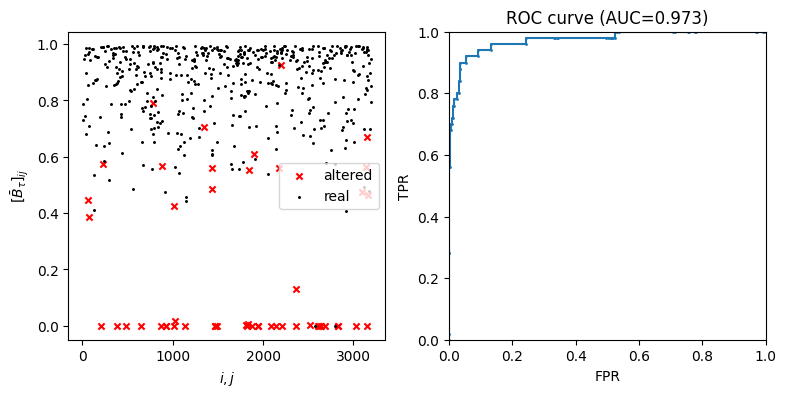

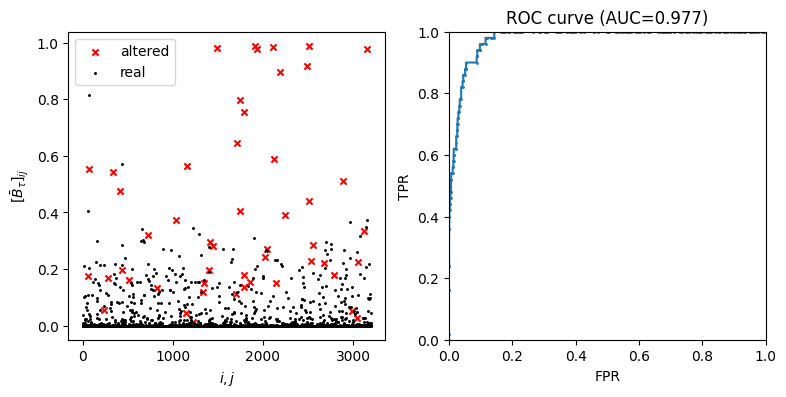

In [12]:
roc_auc, roc_list, actually_positive_list, actually_negative_list = detect_spurious_edges(RGH1_bipartite, 50, D=3, iter=50, random_seed=0)
roc_auc, roc_list, actually_positive_list, actually_negative_list = detect_missing_edges(RGH1_bipartite, 50, D=3, iter=50, random_seed=0)

In [13]:
roc_auc, _, _, _ = detect_spurious_edges(RGH2_bipartite, 50, D=6, iter=50, draw=False)
roc_auc, _, _, _ = detect_missing_edges(RGH2_bipartite, 50, D=6, iter=50, draw=False)

AUC-ROC=0.935
AUC-ROC=0.871


In [14]:
roc_auc, _, _, _ = detect_spurious_edges(RGH3_bipartite, 50, D=6, iter=50, draw=False)
roc_auc, _, _, _ = detect_missing_edges(RGH3_bipartite, 50, D=6, iter=50, draw=False)

AUC-ROC=0.958
AUC-ROC=0.959


In [15]:
roc_auc, _, _, _ = detect_spurious_edges(senate_bipartite, 50, D=32, iter=100, draw=False)
roc_auc, _, _, _ = detect_missing_edges(senate_bipartite, 50, D=32, iter=100, draw=False)

AUC-ROC=0.912
AUC-ROC=0.891


### Community detection

Here we consider the use of geometric embedding for community detection in hypergraphs. After each GDE iteration, the nodes are clustered by applying K-means to their embeddings. We plot the evolution of the Adjusted Rand Index (ARI) over the iterations. Since K-means is highly sensitive to initialization, we report only the best result out of $50$ runs for each GDE iteration.

In [16]:
def clustering_ari(Yu, true_labels, trials=50):
    ari = 0
    for m in range(trials):
        kmeans = KMeans(n_clusters=len(set(true_labels)), random_state=m)
        pred_labels = kmeans.fit_predict(Yu)
        new_ari = adjusted_rand_score(true_labels, pred_labels)
        if new_ari > ari:
            ari = new_ari
    return ari

def compute_clustering_ari_list(Yu_list, true_labels):
    ari_list = []
    for Yu in Yu_list:
        ari = clustering_ari(Yu, true_labels)
        ari_list.append(ari)
    return ari_list

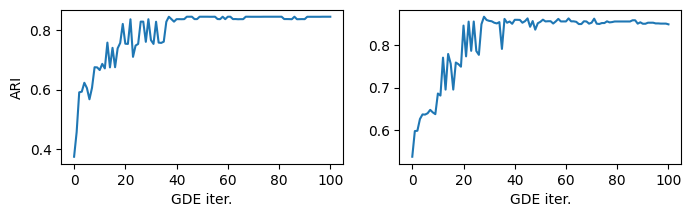

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(8,2))

# Primary school
Yu, Yh, r, tau, history = GDE(primary_school_bipartite, D=16, iter=100, batch_size=256, tau0=10, start='centroid', print_result=False, return_history=True)
ari_list = compute_clustering_ari_list(history['Yu'], primary_school_true_labels)
axs[0].plot(ari_list)
axs[0].set_xlabel('GDE iter.')
axs[0].set_ylabel('ARI')

# High school
Yu, Yh, r, tau, history = GDE(high_school_bipartite, D=16, iter=100, batch_size=256, tau0=10, start='centroid', print_result=False, return_history=True)
ari_list = compute_clustering_ari_list(history['Yu'], high_school_true_labels)
axs[1].plot(ari_list)
axs[1].set_xlabel('GDE iter.')

plt.show()